# Missing Data and Imputation: A Reproducible Simulation Study

This notebook demonstrates a small simulation-based workflow for evaluating how missing data can affect statistical estimation.

The goals of this notebook are to:

- generate reproducible synthetic data from a known linear model,
- introduce missingness in one predictor,
- compare complete-case analysis with simple imputation,
- evaluate coefficient recovery and predictive performance,
- illustrate a clean, transparent statistical workflow using Python.

All data in this notebook are synthetic. No proprietary or employer data are used.

## 1. Setup

We use a fixed random seed so that results are reproducible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 2. Generate synthetic data

The data are generated from the linear model

\[
Y = 2 + 1.5X_1 - 0.8X_2 + \varepsilon,
\]

where \(\varepsilon \sim N(0, 1)\).

Because the true coefficients are known, we can directly assess how well each analysis strategy recovers them.


In [2]:
n = 2000

x1 = rng.normal(0, 1, n)
x2 = rng.normal(0, 1, n)
eps = rng.normal(0, 1, n)

y = 2.0 + 1.5 * x1 - 0.8 * x2 + eps

df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "y": y
})

df.head()


,x1,x2,y
0,0.304717,-0.451951,3.071841
1,-1.039984,-0.665878,1.867944
2,0.750451,0.434010,3.051790
3,0.940565,0.251854,5.448195
4,-1.951035,-1.404792,1.627068


## 3. Introduce missingness

To make the example more realistic than purely random deletion, the probability that `x2` is missing depends on `x1`.

This creates a Missing At Random (MAR)-style mechanism: missingness depends on an observed variable.


In [3]:
missing_prob = 1 / (1 + np.exp(-(-1.0 + 1.2 * df["x1"])))
missing_mask = rng.random(n) < missing_prob

df_missing = df.copy()
df_missing.loc[missing_mask, "x2"] = np.nan

missing_rate = df_missing["x2"].isna().mean()
print(f"Missing rate in x2: {missing_rate:.1%}")


Missing rate in x2: 29.0%


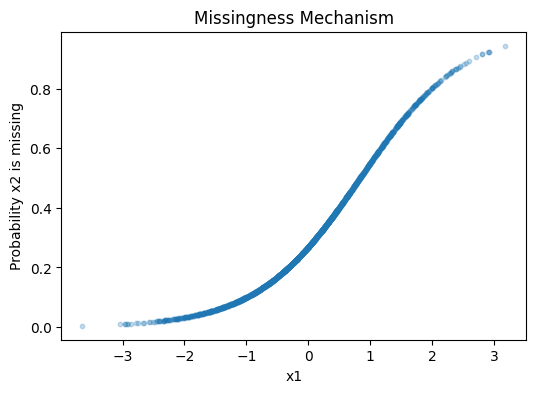

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df_missing["x1"], missing_prob, s=10, alpha=0.25)
ax.set_xlabel("x1")
ax.set_ylabel("Probability x2 is missing")
ax.set_title("Missingness Mechanism")
plt.show()


## 4. Train/test split

The test set is kept complete so that predictive performance can be evaluated against the true observed predictors.


In [5]:
train_df, test_df = train_test_split(
    df_missing,
    test_size=0.30,
    random_state=RANDOM_SEED
)

test_complete = df.loc[test_df.index].copy()

features = ["x1", "x2"]
target = "y"


## 5. Complete-case analysis

Complete-case analysis drops any training row with a missing predictor.

This is simple and often used in practice, but it can reduce sample size and may introduce bias when missingness is related to observed variables.


In [6]:
cc_train = train_df.dropna(subset=features)

cc_model = LinearRegression()
cc_model.fit(cc_train[features], cc_train[target])

cc_pred = cc_model.predict(test_complete[features])
cc_rmse = mean_squared_error(test_complete[target], cc_pred) ** 0.5

cc_results = {
    "method": "Complete case",
    "n_train": len(cc_train),
    "intercept": cc_model.intercept_,
    "beta_x1": cc_model.coef_[0],
    "beta_x2": cc_model.coef_[1],
    "rmse": cc_rmse
}

cc_results


{'method': 'Complete case',
 'n_train': 993,
 'intercept': np.float64(2.0263081648431602),
 'beta_x1': np.float64(1.5076423733134097),
 'beta_x2': np.float64(-0.7580083915337442),
 'rmse': 0.9973987065552617}

## 6. Mean imputation

Next, missing values of `x2` are replaced by the mean estimated from the training data.

Mean imputation is intentionally simple. It is useful here as a baseline and illustrates that preserving sample size does not automatically guarantee unbiased inference.


In [7]:
imputer = SimpleImputer(strategy="mean")

X_train_imp = imputer.fit_transform(train_df[features])
X_test_imp = imputer.transform(test_complete[features])

imp_model = LinearRegression()
imp_model.fit(X_train_imp, train_df[target])

imp_pred = imp_model.predict(X_test_imp)
imp_rmse = mean_squared_error(test_complete[target], imp_pred) ** 0.5

imp_results = {
    "method": "Mean imputation",
    "n_train": len(train_df),
    "intercept": imp_model.intercept_,
    "beta_x1": imp_model.coef_[0],
    "beta_x2": imp_model.coef_[1],
    "rmse": imp_rmse
}

imp_results


{'method': 'Mean imputation',
 'n_train': 1400,
 'intercept': np.float64(2.026781078102481),
 'beta_x1': np.float64(1.521132997110074),
 'beta_x2': np.float64(-0.757808698305882),
 'rmse': 0.9987796866329799}

## 7. Compare coefficient recovery

The true coefficients are:

- intercept = 2.0
- beta for `x1` = 1.5
- beta for `x2` = -0.8


In [8]:
results = pd.DataFrame([cc_results, imp_results])

true_row = pd.DataFrame([{
    "method": "True value",
    "n_train": np.nan,
    "intercept": 2.0,
    "beta_x1": 1.5,
    "beta_x2": -0.8,
    "rmse": np.nan
}])

comparison = pd.concat([true_row, results], ignore_index=True)
comparison


,method,n_train,intercept,beta_x1,beta_x2,rmse
0,True value,NaN,2.000000,1.500000,-0.800000,NaN
1,Complete case,993.0,2.026308,1.507642,-0.758008,0.997399
2,Mean imputation,1400.0,2.026781,1.521133,-0.757809,0.998780


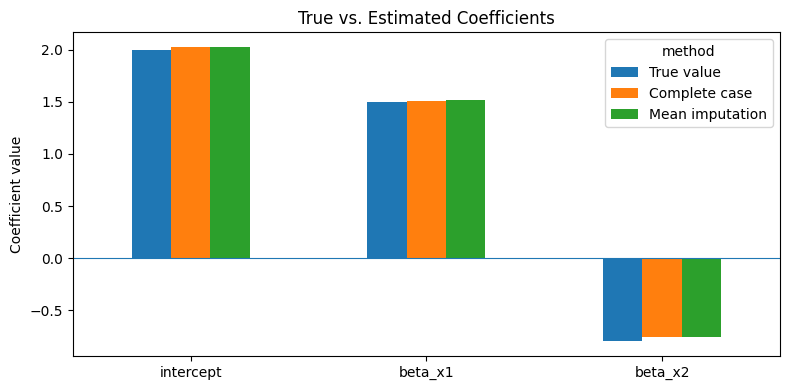

In [9]:
coef_plot = comparison.set_index("method")[["intercept", "beta_x1", "beta_x2"]].T

ax = coef_plot.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("Coefficient value")
ax.set_title("True vs. Estimated Coefficients")
ax.axhline(0, linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Interpretation

In this particular simulation, mean imputation retained substantially more training observations but did not improve coefficient recovery or predictive RMSE relative to complete-case analysis. This result should be interpreted as one realization rather than evidence that complete-case analysis is generally superior. The estimated intercept and slope coefficients were slightly farther from their true values after mean imputation, and the RMSE was also marginally higher. This illustrates that preserving sample size alone does not guarantee better statistical inference or prediction. Simple mean imputation can distort the variance and dependence structure of the predictors, and the observed differences in a single simulation should not be interpreted as a general performance ranking.

This simulation highlights several general points:

1. Missing-data handling is part of the statistical model, not merely a preprocessing detail.
2. Complete-case analysis can discard substantial information.
3. Simple mean imputation preserves sample size but can distort relationships among variables and affect coefficient estimates.
4. Predictive accuracy and inferential accuracy are related but distinct goals.
5. More principled approaches such as regression imputation, multiple imputation, Bayesian modeling, or methods tailored to survey data—may be preferable depending on the data-generating process and inferential objective.

This notebook is intentionally compact and is designed as a methodological demonstration rather than a comprehensive comparison of missing-data methods.

## 9. Monte Carlo Simulation

The preceding comparison is based on a single simulated dataset. To assess the typical behavior of the two missing-data strategies, we repeat the data-generating process many times.

For each simulation:

1. Generate a new synthetic dataset from the same linear model.
2. Introduce missingness in `x2` using the same MAR-style mechanism.
3. Fit a complete-case linear regression.
4. Fit a linear regression after mean imputation.
5. Record coefficient estimation errors and predictive RMSE.

Repeating this process allows us to distinguish systematic behavior from random variation in a single simulated dataset.

In [13]:
def run_simulation(seed, n=2000):
    rng = np.random.default_rng(seed)

    # Generate complete synthetic data
    x1 = rng.normal(0, 1, n)
    x2 = rng.normal(0, 1, n)
    eps = rng.normal(0, 1, n)

    y = 2.0 + 1.5 * x1 - 0.8 * x2 + eps

    complete_df = pd.DataFrame({
        "x1": x1,
        "x2": x2,
        "y": y
    })

    # MAR-style missingness in x2 depending on observed x1
    missing_prob = 1 / (1 + np.exp(-(-1.0 + 1.2 * complete_df["x1"])))
    missing_mask = rng.random(n) < missing_prob

    observed_df = complete_df.copy()
    observed_df.loc[missing_mask, "x2"] = np.nan

    # Use the same train/test indices for both methods
    train_idx, test_idx = train_test_split(
        np.arange(n),
        test_size=0.30,
        random_state=seed
    )

    train_df = observed_df.iloc[train_idx].copy()

    # Keep the test set complete for evaluation
    test_df = complete_df.iloc[test_idx].copy()

    features = ["x1", "x2"]

    # -------------------------
    # Complete-case analysis
    # -------------------------
    cc_train = train_df.dropna(subset=features)

    cc_model = LinearRegression()
    cc_model.fit(cc_train[features], cc_train["y"])

    cc_pred = cc_model.predict(test_df[features])
    cc_rmse = mean_squared_error(test_df["y"], cc_pred) ** 0.5

    # -------------------------
    # Mean imputation
    # -------------------------
    imputer = SimpleImputer(strategy="mean")

    X_train_imp = imputer.fit_transform(train_df[features])
    X_test_imp = imputer.transform(test_df[features])

    imp_model = LinearRegression()
    imp_model.fit(X_train_imp, train_df["y"])

    imp_pred = imp_model.predict(X_test_imp)
    imp_rmse = mean_squared_error(test_df["y"], imp_pred) ** 0.5

    return {
        "missing_rate": train_df["x2"].isna().mean(),

        "cc_n": len(cc_train),
        "cc_intercept": cc_model.intercept_,
        "cc_beta_x1": cc_model.coef_[0],
        "cc_beta_x2": cc_model.coef_[1],
        "cc_rmse": cc_rmse,

        "imp_n": len(train_df),
        "imp_intercept": imp_model.intercept_,
        "imp_beta_x1": imp_model.coef_[0],
        "imp_beta_x2": imp_model.coef_[1],
        "imp_rmse": imp_rmse,
    }

In [14]:
N_SIM = 500

simulation_results = pd.DataFrame(
    run_simulation(seed)
    for seed in range(N_SIM)
)

simulation_results.head()

,missing_rate,cc_n,cc_intercept,cc_beta_x1,cc_beta_x2,cc_rmse,imp_n,imp_intercept,imp_beta_x1,imp_beta_x2,imp_rmse
0,0.301429,978,2.037090,1.526895,-0.877331,0.958492,1400,2.019651,1.511922,-0.877563,0.957479
1,0.303571,975,1.994433,1.464689,-0.774291,1.036510,1400,2.043570,1.511689,-0.772472,1.039052
2,0.306429,971,2.069653,1.484766,-0.801411,0.970214,1400,2.096098,1.516392,-0.801500,0.971190
3,0.315714,958,1.991229,1.444757,-0.719739,1.007441,1400,1.984816,1.451901,-0.719463,1.006827
4,0.315000,959,2.053664,1.562688,-0.761734,0.985275,1400,2.064067,1.553400,-0.762033,0.984693


In [15]:
simulation_results.shape

(500, 11)

In [16]:
true_values = {
    "intercept": 2.0,
    "beta_x1": 1.5,
    "beta_x2": -0.8
}

for param, true_value in true_values.items():
    simulation_results[f"cc_{param}_error"] = (
        simulation_results[f"cc_{param}"] - true_value
    )

    simulation_results[f"imp_{param}_error"] = (
        simulation_results[f"imp_{param}"] - true_value
    )

    simulation_results[f"cc_{param}_abs_error"] = (
        simulation_results[f"cc_{param}_error"].abs()
    )

    simulation_results[f"imp_{param}_abs_error"] = (
        simulation_results[f"imp_{param}_error"].abs()
    )

In [17]:
summary = pd.DataFrame({
    "Metric": [
        "Mean intercept bias",
        "Mean |intercept error|",
        "Mean beta_x1 bias",
        "Mean |beta_x1 error|",
        "Mean beta_x2 bias",
        "Mean |beta_x2 error|",
        "Mean RMSE"
    ],

    "Complete case": [
        simulation_results["cc_intercept_error"].mean(),
        simulation_results["cc_intercept_abs_error"].mean(),

        simulation_results["cc_beta_x1_error"].mean(),
        simulation_results["cc_beta_x1_abs_error"].mean(),

        simulation_results["cc_beta_x2_error"].mean(),
        simulation_results["cc_beta_x2_abs_error"].mean(),

        simulation_results["cc_rmse"].mean()
    ],

    "Mean imputation": [
        simulation_results["imp_intercept_error"].mean(),
        simulation_results["imp_intercept_abs_error"].mean(),

        simulation_results["imp_beta_x1_error"].mean(),
        simulation_results["imp_beta_x1_abs_error"].mean(),

        simulation_results["imp_beta_x2_error"].mean(),
        simulation_results["imp_beta_x2_abs_error"].mean(),

        simulation_results["imp_rmse"].mean()
    ]
})

summary

,Metric,Complete case,Mean imputation
0,Mean intercept bias,-0.000259,0.000038
1,Mean |intercept error|,0.026650,0.024107
2,Mean beta_x1 bias,0.000725,0.001230
3,Mean |beta_x1 error|,0.029121,0.024758
4,Mean beta_x2 bias,-0.001467,-0.001453
5,Mean |beta_x2 error|,0.027419,0.027393
6,Mean RMSE,1.002555,1.002309


In [18]:
comparison_rates = pd.Series({
    "Mean imputation lower RMSE": (
        simulation_results["imp_rmse"]
        < simulation_results["cc_rmse"]
    ).mean(),

    "Mean imputation closer for intercept": (
        simulation_results["imp_intercept_abs_error"]
        < simulation_results["cc_intercept_abs_error"]
    ).mean(),

    "Mean imputation closer for beta_x1": (
        simulation_results["imp_beta_x1_abs_error"]
        < simulation_results["cc_beta_x1_abs_error"]
    ).mean(),

    "Mean imputation closer for beta_x2": (
        simulation_results["imp_beta_x2_abs_error"]
        < simulation_results["cc_beta_x2_abs_error"]
    ).mean(),
})

comparison_rates

Mean imputation lower RMSE              0.536
Mean imputation closer for intercept    0.548
Mean imputation closer for beta_x1      0.574
Mean imputation closer for beta_x2      0.544
dtype: float64

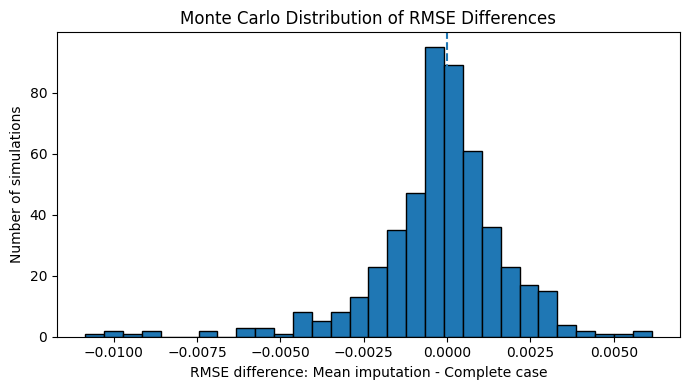

In [19]:
rmse_diff = (
    simulation_results["imp_rmse"]
    - simulation_results["cc_rmse"]
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(rmse_diff, bins=30, edgecolor="black")
ax.axvline(0, linestyle="--")

ax.set_xlabel("RMSE difference: Mean imputation - Complete case")
ax.set_ylabel("Number of simulations")
ax.set_title("Monte Carlo Distribution of RMSE Differences")

plt.tight_layout()
plt.show()

### Monte Carlo Interpretation

The single-dataset example above suggested that mean imputation performed slightly worse than complete-case analysis for both coefficient recovery and predictive RMSE. However, that comparison reflects only one realization of the data-generating process.

Across 500 Monte Carlo simulations, the two methods performed very similarly overall. Mean imputation produced a lower predictive RMSE in 53.6% of simulations and yielded coefficient estimates closer to the true values in 54.8% of simulations for the intercept, 57.4% for $\beta_1$, and 54.4% for $\beta_2$. The distribution of RMSE differences was concentrated near zero, indicating that neither method consistently dominated the other under this particular simulation design.

These results illustrate why conclusions about statistical procedures should not be based on a single simulated dataset. Repeated simulation provides a more stable assessment of estimator behavior by separating systematic differences from sampling variability.

More broadly, preserving additional observations through simple mean imputation does not guarantee substantially better inference or prediction. Its performance depends on the missingness mechanism, the dependence structure among variables, and the inferential objective. More principled approaches such as multiple imputation, regression imputation, Bayesian methods, or survey-specific procedures may be more appropriate in applied settings.

## 10. Reproducibility notes

Environment requirements:

```text
numpy
pandas
matplotlib
scikit-learn
```

The notebook uses only synthetic data and a fixed random seed.
